              word level  pos  \
0            a bit    a2  NaN   
1       a bit more    b1  NaN   
2      a bit of a…    b2  NaN   
3     a bit of sth    b1  NaN   
4  a couple of sth    a2  NaN   

                                      definition_url  \
0  https://www.oxfordlearnersdictionaries.com/def...   
1  https://www.oxfordlearnersdictionaries.com/def...   
2  https://www.oxfordlearnersdictionaries.com/def...   
3  https://www.oxfordlearnersdictionaries.com/def...   
4  https://www.oxfordlearnersdictionaries.com/def...   

                                           voice_url  
0  https://www.oxfordlearnersdictionaries.com/med...  
1  https://www.oxfordlearnersdictionaries.com/med...  
2  https://www.oxfordlearnersdictionaries.com/med...  
3  https://www.oxfordlearnersdictionaries.com/med...  
4  https://www.oxfordlearnersdictionaries.com/med...  
Index(['word', 'level', 'pos', 'definition_url', 'voice_url'], dtype='str')


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_3443/1780805980.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]



CLUSTER 0
['all day', 'at the end of the day', 'every day', 'one day', 'that day', 'the next day', 'these days', 'x hours a day']

CLUSTER 1
['a bit', 'a bit more', 'a bit of a…', 'a few', 'a good idea', 'a great deal', 'a kind of...', 'a little', 'a little bit', 'a little more']

CLUSTER 2
['as far as i am concerned', 'as far as sb/sth is concerned', 'concerned about sth', 'concerned with sth', 'far away', 'far from sth', 'far more', 'far too', 'so far']

CLUSTER 3
['a bit of sth', 'a couple of sth', 'a lot of sth', 'a means of sth', 'a number of sth', 'a range of sth', 'a variety of sth', 'able to do sth', 'access to sth', 'account for sth']

CLUSTER 4
['along with sb/sth', 'apply to sb/sth', 'as for sb/sth', 'at the expense of sb/sth', 'attached to sb/sth', 'away from sb/sth', 'back sb/sth up', 'bad for sb/sth', 'be known as sb/sth', 'be surrounded by sb/sth']


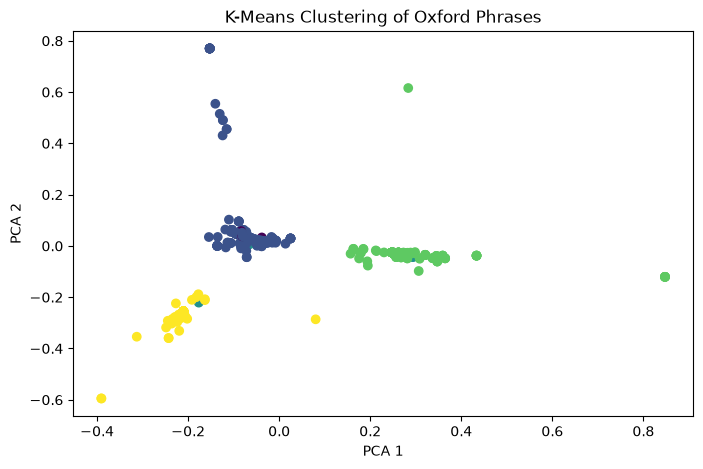

In [1]:
# 1. Install libraries
!pip install pandas scikit-learn nltk matplotlib -q

# 2. Import libraries
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 3. Download NLTK data
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

# 4. Load dataset
df = pd.read_csv("oxford-phrase.csv")
print(df.head())
print(df.columns)

# 5. Select text column
text_col = df.select_dtypes(include="object").columns[0]

# 6. NLP preprocessing
stop_words = set(stopwords.words("english"))
lemma = WordNetLemmatizer()

def clean(text):
    text = re.sub(r"[^a-zA-Z\s]", "", str(text).lower())
    words = [lemma.lemmatize(w) for w in text.split()
             if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df[text_col].fillna("").apply(clean)

# 7. TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df["clean_text"])

# 8. K-Means clustering
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 9. Show clusters
for i in range(k):
    print("\nCLUSTER", i)
    print(df[df["cluster"] == i][text_col].head(10).to_list())

# 10. Visualise
pca = PCA(n_components=2)
points = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,5))
plt.scatter(points[:,0], points[:,1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering of Oxford Phrases")
plt.show()

# 11. Save results
df.to_csv("oxford-phrase-clustered.csv", index=False)